# 47 · NIAMS PRE samples against healthy children · bulk_RNA_seq

Reads the raw counts of notebook 40 and of notebook 45, and the ComBat-seq counts of notebook 40 for display.
Writes `de_NIAMS_PRE_<group>_vs_<healthy block>.csv` and `top_genes_NIAMS_PRE_<group>_vs_<healthy block>.csv`
in `data/run_artifacts/CANDLE_SAVI/`, and figures to `figures/CANDLE_SAVI/`.

**Objective.** Compare the NIAMS samples taken before treatment (Treatment = PRE; CANDLE and SAVI, notebook 43)
with the blood of healthy children (notebook 45), for each healthy block.

**One fact to keep in mind.** The healthy children were sequenced in a different lab; a gene that differs
between them and the PRE samples may differ because of disease or because of the lab. The interferon response
genes are the check, as in notebook 46.

**Method.** As in notebook 46: limma-voom on the raw counts of the genes common to both sources, TMM
normalization, the patient as a blocking factor; batch terms for the NIAMS sequencing cohort and the GSE69529
set; top genes: adjusted p < 0.05 and fold change at least 2.

## Read the two sources

In [1]:
source("../src/paths.R")
suppressMessages({library(limma); library(edgeR); library(ComplexHeatmap); library(circlize)})
x  <- readRDS(art("CANDLE_SAVI", "counts_raw.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
hc <- readRDS(art("CANDLE_SAVI", "healthy_counts.rds")); hs <- readRDS(art("CANDLE_SAVI", "healthy_samples.rds"))
pre <- s[s$Sequencing_Facility == "NIAMS" & s$Treatment == "PRE", ]
genes <- intersect(rownames(x$counts), rownames(hc))
meta <- rbind(data.frame(sample = pre$sample, patient = pre$patient, group = paste0(pre$diagnosis, "_PRE"), batch = pre$batch),
              data.frame(sample = hs$sample, patient = hs$sample, group = hs$block, batch = paste0("GSE69529-", hs$set)))
counts <- cbind(x$counts[genes, pre$sample], hc[genes, hs$sample])
c(genes = length(genes), samples = ncol(counts), patients = length(unique(meta$patient))); table(meta$group)

genes  samples patients 
   15384       86       59


    CANDLE_PRE       SAVI_PRE  healthy_2plus healthy_under2 
            31             12             22             21 

**Explanation**
- `pre` keeps the NIAMS samples with Treatment = PRE (notebook 43).
- `genes` keeps the genes in both sources; `meta` stacks the sample information: sample, patient, group
  (`CANDLE_PRE`, `SAVI_PRE`, or the healthy block) and batch; each healthy child is its own patient.
- `counts` puts the two count tables side by side, in the order of `meta`.

**Result.** 15,384 genes in both sources; 86 samples from 59 patients: CANDLE PRE 31, SAVI PRE 12, healthy under 2 21,
healthy 2 or older 22.

## Design, filter and voom with the patient as a block

In [2]:
meta$group <- factor(meta$group, levels = c("CANDLE_PRE", "SAVI_PRE", "healthy_under2", "healthy_2plus"))
meta$batch_term <- relevel(factor(make.names(ifelse(meta$batch %in% c("NIAMS-Batch1", "GSE69529-set1"), "reference", meta$batch))), ref = "reference")
design <- model.matrix(~ 0 + group + batch_term, meta); colnames(design) <- sub("^group", "", colnames(design))
dge  <- DGEList(counts); keep <- filterByExpr(dge, group = meta$group)
dge  <- calcNormFactors(dge[keep, , keep.lib.sizes = FALSE])
v    <- voom(dge, design)
cor1 <- duplicateCorrelation(v, design, block = meta$patient)$consensus
v    <- voom(dge, design, block = meta$patient, correlation = cor1)
cor2 <- duplicateCorrelation(v, design, block = meta$patient)$consensus
fit  <- lmFit(v, design, block = meta$patient, correlation = cor2)
c(coefficients = ncol(design), rank = qr(design)$rank, genes_kept = sum(keep), correlation = round(cor2, 3))
table(batch_term = meta$batch_term, group = meta$group)

coefficients         rank   genes_kept  correlation 
        6.00         6.00     12823.00         0.19

                  group
batch_term         CANDLE_PRE SAVI_PRE healthy_under2 healthy_2plus
  reference                23       11             11            13
  GSE69529.set2             0        0             10             9
  NIAMS.unlabelled          8        1              0             0

**Explanation**
- `batch_term`: the NIAMS unlabelled cohort relative to Batch1 (both hold CANDLE and SAVI samples), and GSE69529
  set 2 relative to set 1 (both hold children of both healthy blocks); the other samples share the reference
  level.
- The design, filter, TMM, voom, `duplicateCorrelation` and fit are those of notebook 46.

**Result.** 6 coefficients, all estimable; 12,823 genes pass the filter; the correlation between samples of the same
patient is 0.19.

## CANDLE PRE, SAVI PRE and all PRE against each healthy block

In [3]:
con <- unlist(lapply(c("healthy_under2", "healthy_2plus"), function(h)
  setNames(c(paste0("CANDLE_PRE - ", h), paste0("SAVI_PRE - ", h), paste0("(CANDLE_PRE + SAVI_PRE)/2 - ", h)),
           paste0("NIAMS_PRE_", c("CANDLE", "SAVI", "all"), "_vs_", h))))
cm   <- makeContrasts(contrasts = con, levels = design); colnames(cm) <- names(con)
fit2 <- eBayes(contrasts.fit(fit, cm))
tabs <- lapply(setNames(colnames(cm), colnames(cm)), function(k) {
  t <- topTable(fit2, coef = k, number = Inf, sort.by = "P"); data.frame(gene_id = rownames(t), gene_name = x$genes[rownames(t), "gene_name"], t, row.names = NULL) })
top  <- lapply(tabs, function(t) t[t$adj.P.Val < 0.05 & abs(t$logFC) >= 1, ])
for (k in names(tabs)) {
  write.csv(tabs[[k]], art("CANDLE_SAVI", sprintf("de_%s.csv", k)), row.names = FALSE)
  write.csv(top[[k]][, c("gene_id", "gene_name", "logFC", "AveExpr", "t", "adj.P.Val")], art("CANDLE_SAVI", sprintf("top_genes_%s.csv", k)), row.names = FALSE)
}
data.frame(comparison = names(tabs), adj_p_below_0.05 = sapply(tabs, function(t) sum(t$adj.P.Val < 0.05)),
           top_up = sapply(top, function(t) sum(t$logFC > 0)), top_down = sapply(top, function(t) sum(t$logFC < 0)), row.names = NULL)

comparison,adj_p_below_0.05,top_up,top_down
<chr>,<int>,<int>,<int>
NIAMS_PRE_CANDLE_vs_healthy_under2,7931,2396,952
NIAMS_PRE_SAVI_vs_healthy_under2,6200,2312,535
NIAMS_PRE_all_vs_healthy_under2,7716,2342,679
NIAMS_PRE_CANDLE_vs_healthy_2plus,7865,2295,899
NIAMS_PRE_SAVI_vs_healthy_2plus,6147,2218,507
NIAMS_PRE_all_vs_healthy_2plus,7643,2244,625


**Explanation**
- Six comparisons: for each healthy block, CANDLE PRE, SAVI PRE, and all PRE (the mean of the CANDLE and SAVI
  means) minus that block. A positive log2 fold change means higher in the PRE samples.
- Full tables and top genes are written as CSV files, as in notebook 46.

**Result.** 6,147 to 7,931 of the 12,823 genes have adjusted p < 0.05; 2,725 to 3,348 are top genes, most of them
higher in the PRE samples. As in notebook 46, at this scale the lab difference and the disease difference cannot
be told apart.

## Check. The interferon response genes and the NF-kB-only controls

In [4]:
GENES <- data.frame(gene_id = rownames(x$genes), gene_name = x$genes$gene_name)
GENES <- GENES[GENES$gene_id %in% rownames(dge), ]
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))
round(t(sapply(tabs, function(t) { m <- t[match(ifn$gene_id, t$gene_id), ]
  c(IRG28_median_log2FC = median(m$logFC[ifn$set == "IRG-28"], na.rm = TRUE),
    IRG28_up_top = sum(m$adj.P.Val[ifn$set == "IRG-28"] < 0.05 & m$logFC[ifn$set == "IRG-28"] >= 1, na.rm = TRUE),
    NFkB11_median_log2FC = median(m$logFC[ifn$set == "NF-kB-11"], na.rm = TRUE),
    NFkB11_up_top = sum(m$adj.P.Val[ifn$set == "NF-kB-11"] < 0.05 & m$logFC[ifn$set == "NF-kB-11"] >= 1, na.rm = TRUE)) })), 2)

interferon_genes_found    control_genes_found 
                    28                     10

,IRG28_median_log2FC,IRG28_up_top,NFkB11_median_log2FC,NFkB11_up_top
NIAMS_PRE_CANDLE_vs_healthy_under2,1.91,26,-0.17,0
NIAMS_PRE_SAVI_vs_healthy_under2,1.39,15,-0.07,1
NIAMS_PRE_all_vs_healthy_under2,1.59,23,0.11,0
NIAMS_PRE_CANDLE_vs_healthy_2plus,2.28,26,-0.14,0
NIAMS_PRE_SAVI_vs_healthy_2plus,1.81,21,-0.12,0
NIAMS_PRE_all_vs_healthy_2plus,2.02,26,0.05,0


**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The line `c(interferon_genes_found = ...)` counts the genes found among the genes that pass the filter.
- The table gives, for each comparison, the median log2 fold change of the 28 interferon response genes and of
  the 11 controls, and how many of each are top genes up in the PRE samples.

**Result.** 10 of the 11 controls pass the filter. The 28 interferon response genes are higher in the PRE samples
than in healthy children: median log2 fold change 1.39 to 2.28; 15 to 26 of the 28 are top genes up. The
controls stay near the healthy level (median -0.17 to 0.11; at most 1 is a top gene up).

## Heatmaps

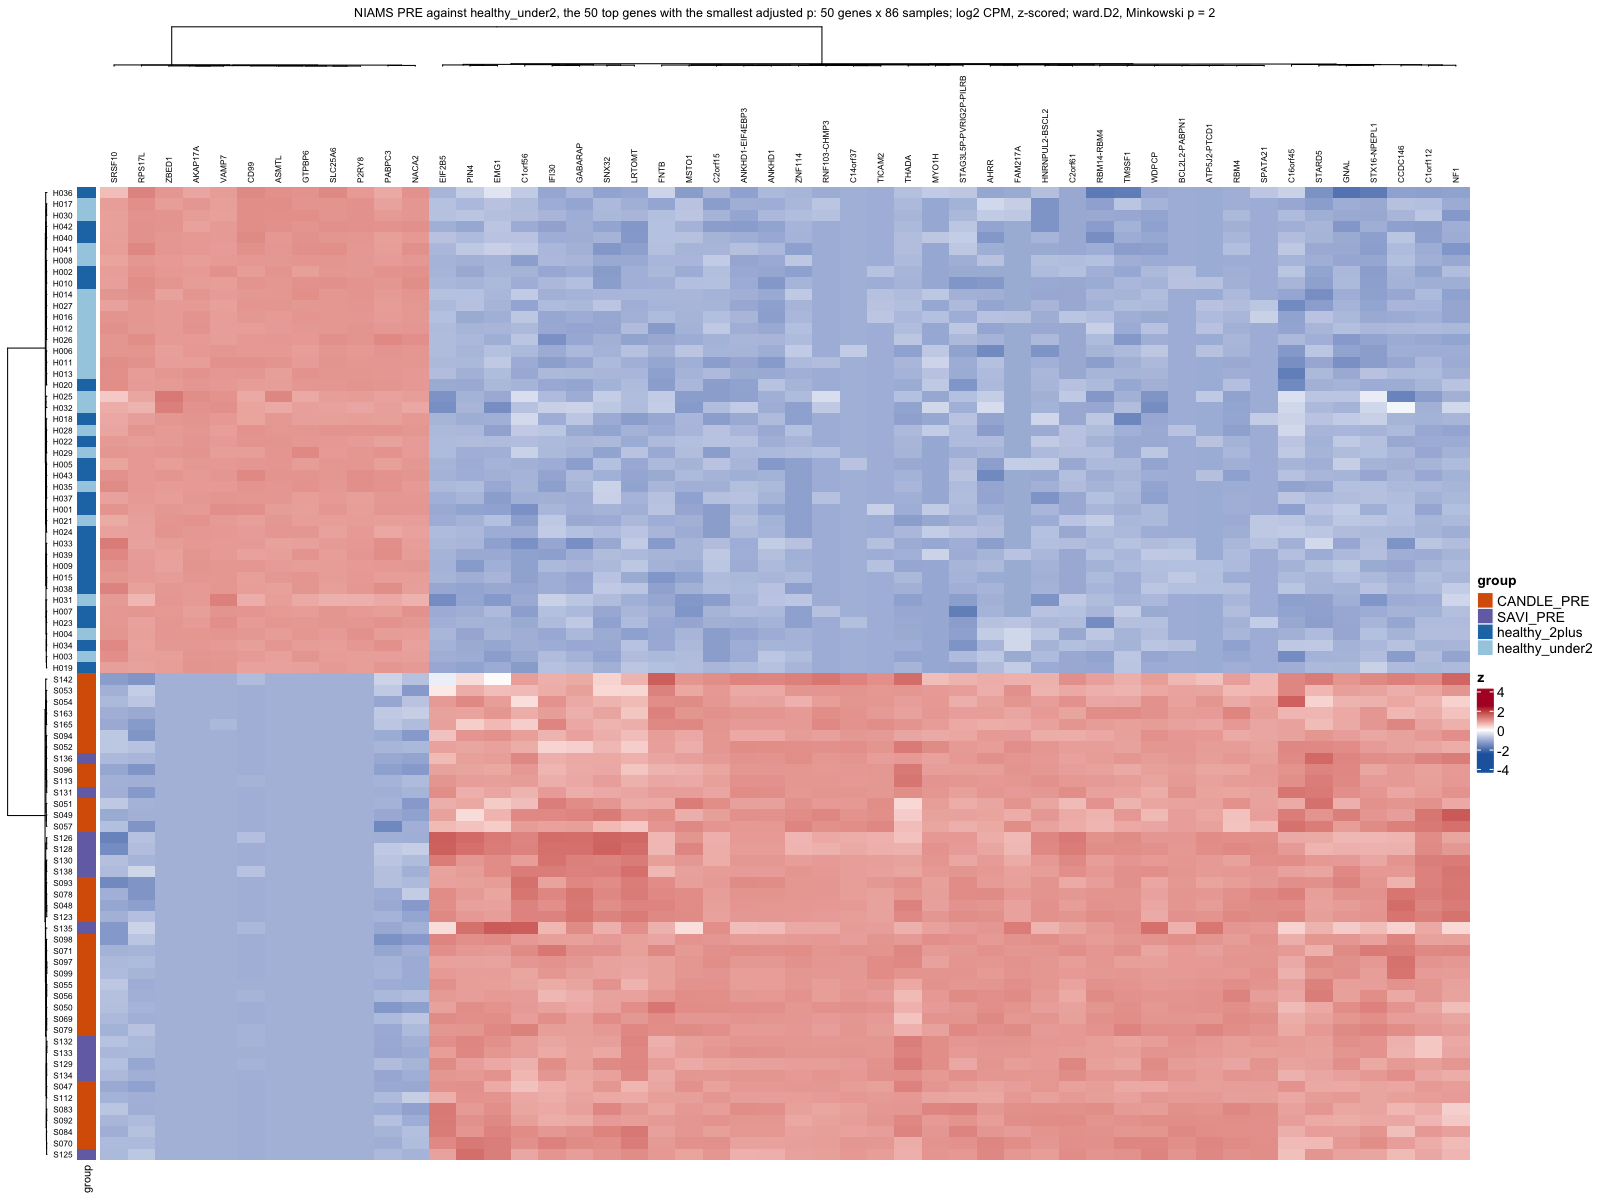

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



saved, not shown: 47_heatmap_NIAMS_PRE_vs_healthy_under2.png (215 x 12 inches) 


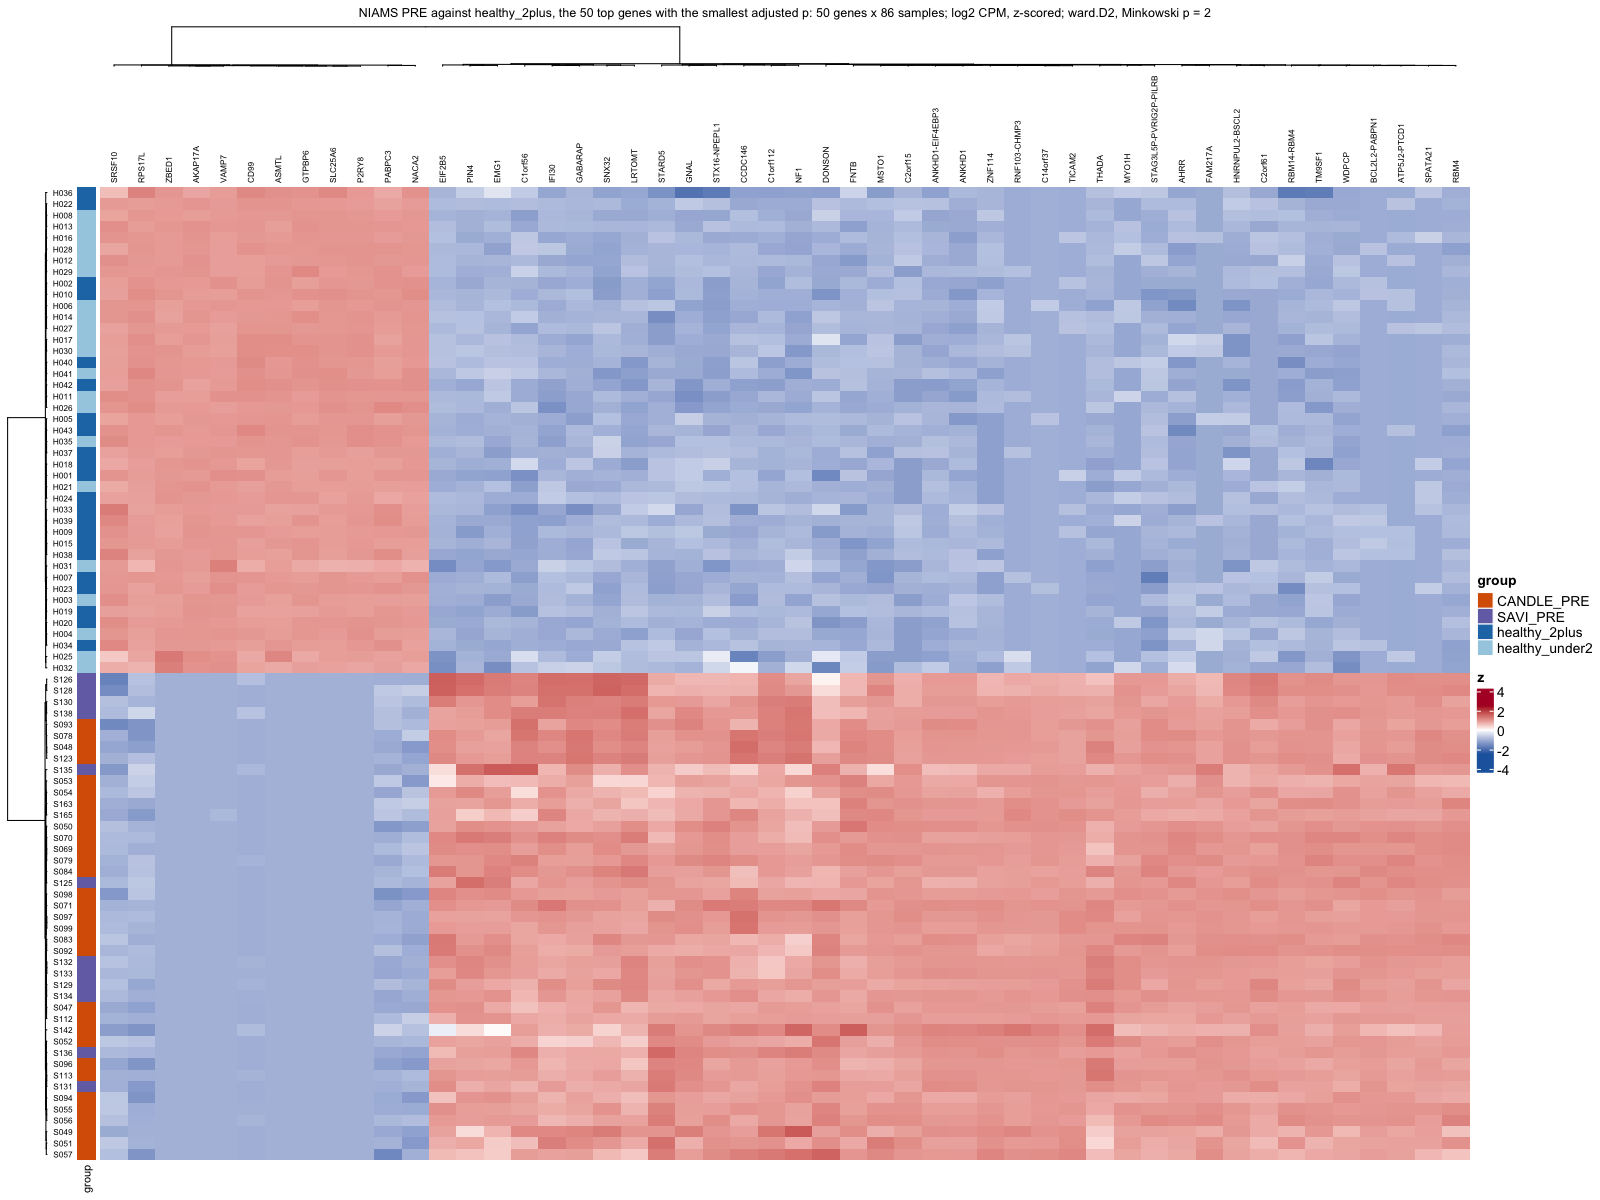

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



saved, not shown: 47_heatmap_NIAMS_PRE_vs_healthy_2plus.png (205 x 12 inches) 


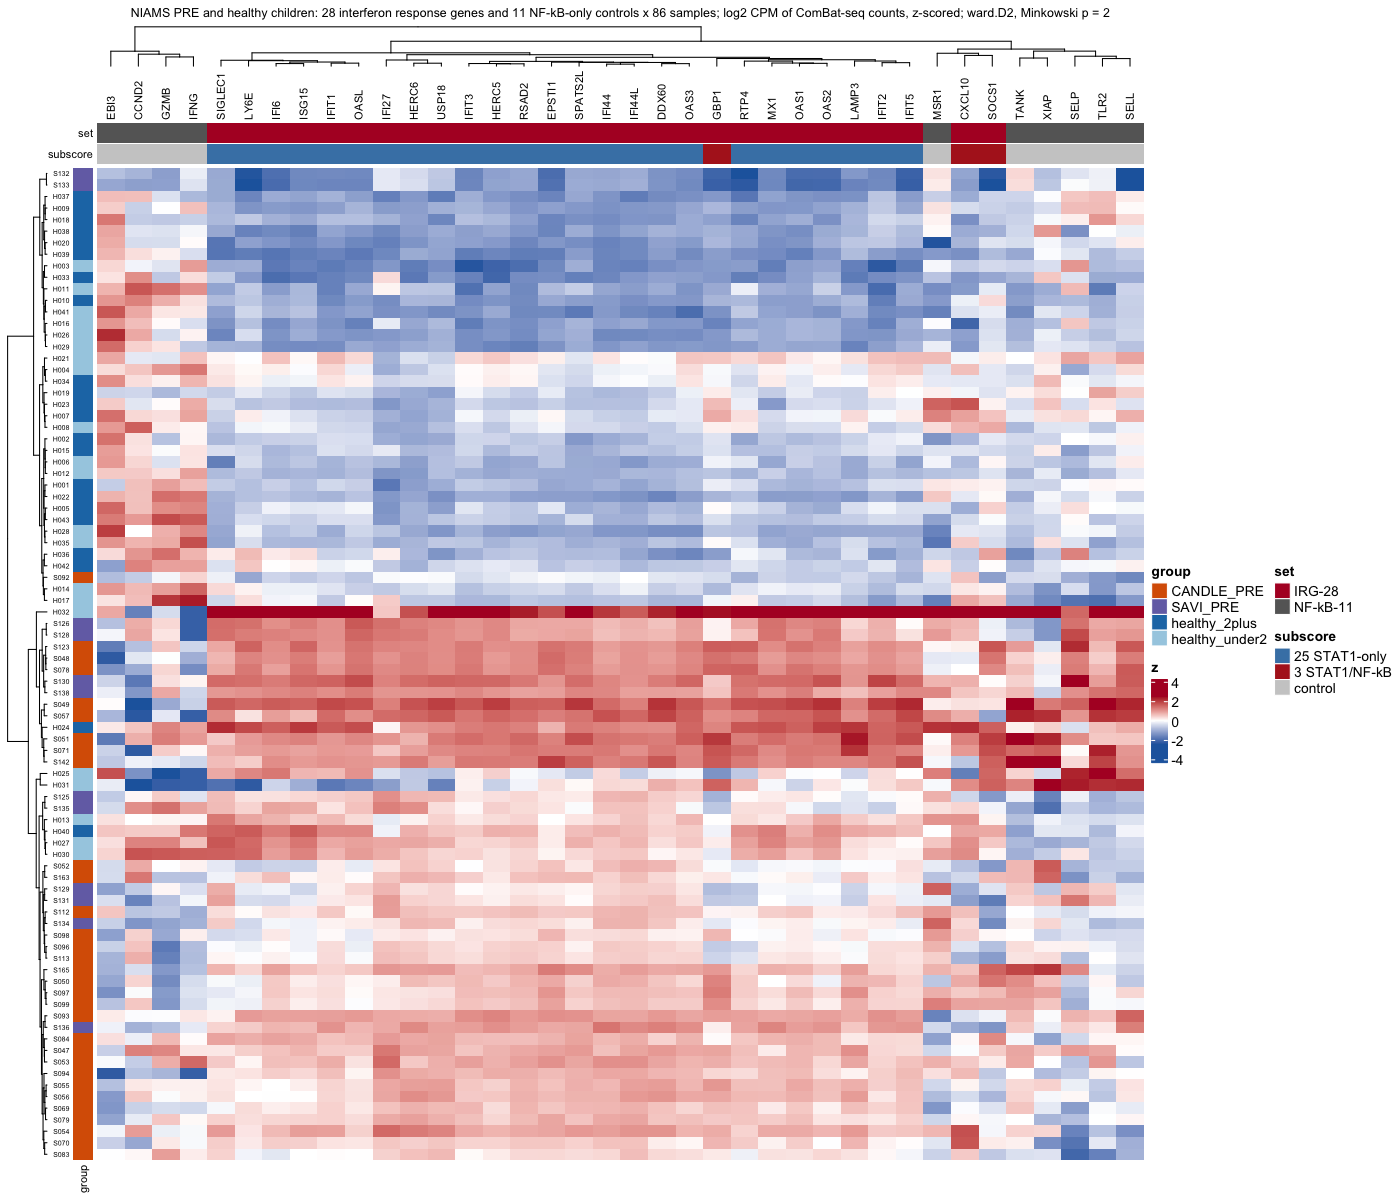

      group
branch CANDLE_PRE SAVI_PRE healthy_under2 healthy_2plus
     1         30       10              6             2
     2          1        2             15            20

In [5]:
xc <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds"))
logcpm <- cpm(calcNormFactors(DGEList(cbind(round(xc$counts[genes, pre$sample]), hc[genes, hs$sample])[rownames(dge), ])), log = TRUE)
left <- rowAnnotation(group = as.character(meta$group),
                      col = list(group = c(CANDLE_PRE = "#D95F02", SAVI_PRE = "#7570B3", healthy_under2 = "#A6CEE3", healthy_2plus = "#1F78B4")),
                      annotation_name_gp = gpar(fontsize = 8))
show_and_save <- function(ht, file, w, h, show = TRUE) {
  for (res in if (show) c(300, 100) else 300) {
    f <- if (res == 300) fig("CANDLE_SAVI", file) else tempfile(fileext = ".png")
    png(f, width = w, height = h, units = "in", res = res); draw(ht); invisible(dev.off())
  }
  if (show) IRdisplay::display_png(file = f) else cat("saved, not shown:", file, sprintf("(%.0f x %.0f inches)", w, h), "\n")
}
heat <- function(g, title) {
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); H <- H[, colSums(is.na(H)) == 0, drop = FALSE]
  Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hcl <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hr, cluster_columns = hcl, row_dend_side = "left", column_dend_side = "top",
          row_names_side = "left", row_names_gp = gpar(fontsize = 6), column_names_side = "top",
          column_labels = g$gene_name[match(colnames(H), g$gene_id)], column_names_gp = gpar(fontsize = 6),
          left_annotation = left, column_title_gp = gpar(fontsize = 9),
          column_title = sprintf("%s: %d genes x %d samples; log2 CPM, z-scored; ward.D2, Minkowski p = 2", title, ncol(H), nrow(H)))
}
for (h in c("healthy_under2", "healthy_2plus")) {
  tg <- top[[paste0("NIAMS_PRE_all_vs_", h)]]
  show_and_save(heat(head(tg, 50), sprintf("NIAMS PRE against %s, the 50 top genes with the smallest adjusted p", h)),
                sprintf("47_heatmap_NIAMS_PRE_vs_%s_top50.png", h), 16, 12)
  if (nrow(tg) > 50) show_and_save(heat(tg, sprintf("NIAMS PRE against %s, all top genes", h)), sprintf("47_heatmap_NIAMS_PRE_vs_%s.png", h),
                                   max(16, 4 + 0.07 * nrow(tg)), 12, show = FALSE)
}
r <- ifn_heat(logcpm[ifn$gene_id[!is.na(ifn$gene_id)], ], left, "NIAMS PRE and healthy children")
show_and_save(r$ht, "47_interferon_heatmap.png", 14, 12)
table(branch = cutree(r$rows, 2), group = meta$group)

**Explanation**
- As in notebook 46: the PRE samples use the ComBat-seq counts of notebook 40 for display; heatmaps of the 50
  top genes of all PRE against each healthy block (all top genes saved), and of the interferon genes, with the
  first split of the sample tree crossed with group.

**Result.** In the interferon heatmap the first split of the sample tree puts 30 of 31 CANDLE PRE and 10 of 12 SAVI
PRE samples on one branch with 8 healthy children, and 35 of the 43 healthy children on the other with 3 PRE
samples.

## References

1. Law CW, Chen Y, Shi W, Smyth GK. voom: precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biol* 2014;15:R29.
2. Ritchie ME, Phipson B, Wu D, Hu Y, Law CW, Shi W, Smyth GK. limma powers differential expression analyses for RNA-sequencing and microarray studies. *Nucleic Acids Res* 2015;43:e47.
3. Smyth GK, Michaud J, Scott HS. Use of within-array replicate spots for assessing differential expression in microarray experiments. *Bioinformatics* 2005;21:2067-2075.
4. Smyth GK. Linear models and empirical Bayes methods for assessing differential expression in microarray experiments. *Stat Appl Genet Mol Biol* 2004;3:Article3.
5. Benjamini Y, Hochberg Y. Controlling the false discovery rate: a practical and powerful approach to multiple testing. *J R Stat Soc B* 1995;57:289-300.
6. Robinson MD, McCarthy DJ, Smyth GK. edgeR: a Bioconductor package for differential expression analysis of digital gene expression data. *Bioinformatics* 2010;26:139-140.
7. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
8. Chen Y, Lun ATL, Smyth GK. From reads to genes to pathways: differential expression analysis of RNA-Seq experiments using Rsubread and the edgeR quasi-likelihood pipeline. *F1000Research* 2016;5:1438.
9. Zhang Y, Parmigiani G, Johnson WE. ComBat-seq: batch effect adjustment for RNA-seq count data. *NAR Genom Bioinform* 2020;2:lqaa078.
10. Gu Z, Eils R, Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics* 2016;32:2847-2849.
11. Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics* 2014;30:2811-2812.
12. Ward JH. Hierarchical grouping to optimize an objective function. *J Am Stat Assoc* 1963;58:236-244.
13. Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *J Classif* 2014;31:274-295.
14. Kim H, et al. Development of a validated interferon score using NanoString technology. *J Interferon Cytokine Res* 2018;38:171-185.
15. de Jesus AA, et al. Distinct interferon signatures and cytokine patterns define additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669-1682.
16. DeBerg HA, et al. Shared and organism-specific host responses to childhood diarrheal diseases revealed by whole blood transcript profiling. *PLoS One* 2018;13:e0192082.